In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

"""
Testing should only be performed on the real dataset.
"""

real_train_X = pd.read_csv("/work/datasets/preprocessed/real_X_train.csv")
real_test_X = pd.read_csv("/work/datasets/preprocessed/real_X_test.csv")
real_train_y = pd.read_csv("/work/datasets/preprocessed/real_y_train.csv")
real_test_y = pd.read_csv("/work/datasets/preprocessed/real_y_test.csv")


synth_train_X = pd.read_csv("/work/datasets/preprocessed/synthetic_X_train.csv")
synth_test_X = pd.read_csv("/work/datasets/preprocessed/synthetic_X_test.csv")
synth_train_y = pd.read_csv("/work/datasets/preprocessed/synthetic_y_train.csv")
synth_test_y = pd.read_csv("/work/datasets/preprocessed/synthetic_y_test.csv")


print(real_train_y.shape)
print(real_test_y.shape)
print(synth_train_y.shape)
print(synth_test_y.shape)

# Initialize LabelEncoder and transform labels
le = LabelEncoder()
real_train_y = le.fit_transform(real_train_y)
real_test_y = le.transform(real_test_y)
synth_train_y = le.transform(synth_train_y)
synth_test_y = le.transform(synth_test_y)

real_train_y = pd.Series(real_train_y)
real_test_y = pd.Series(real_test_y)
synth_train_y = pd.Series(synth_train_y)
synth_test_y = pd.Series(synth_test_y)

# Convert numpy arrays back to pandas Series for concatenation
real_train_y_series = pd.Series(real_train_y)
synth_train_y_series = pd.Series(synth_train_y)

DATASETS = {
    "real": {
        "X": {
            "train": real_train_X,
            "test": real_test_X
        },
        "y": {
            "train": real_train_y,
            "test": real_test_y
        }
    },
    "synthetic": {
        "X": {
            "train": synth_train_X,
            "test": real_test_X
        },
        "y": {
            "train": synth_train_y,
            "test": real_test_y
        }
    },
    "concatenated": {
        "X": {
            "train": pd.concat([real_train_X, synth_train_X]),
            "test": real_test_X
        },
        "y": {
            "train": pd.concat([real_train_y_series, synth_train_y_series]),
            "test": real_test_y
        }
    }
}

DATASETS

(1688, 1)
(423, 1)
(15112, 1)
(3779, 1)
/root/venv/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:115: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/root/venv/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


{'real': {'X': {'train':            Age  CAEC_Frequently  CAEC_Sometimes  CAEC_no  CALC_Frequently  \
   0    -0.522124              0.0             0.0      0.0              0.0   
   1    -0.533953              0.0             1.0      0.0              0.0   
   2    -0.222692              0.0             1.0      0.0              0.0   
   3    -0.390041              1.0             0.0      0.0              0.0   
   4     0.265136              0.0             1.0      0.0              0.0   
   ...        ...              ...             ...      ...              ...   
   1683  1.257405              0.0             1.0      0.0              0.0   
   1684 -0.206889              0.0             1.0      0.0              0.0   
   1685 -0.208489              0.0             1.0      0.0              0.0   
   1686 -0.206889              0.0             1.0      0.0              0.0   
   1687 -0.679742              0.0             1.0      0.0              0.0   
   
         CALC_

In [2]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
from time import time

def train_evaluate_classifiers(X_train, y_train, X_test, y_test, random_state=42):
    """
    Train and evaluate multiple classifiers using 5-fold cross validation
    
    Parameters:
    -----------
    X_train : pd.DataFrame
        Training features
    y_train : pd.Series
        Training labels
    X_test : pd.DataFrame
        Test features
    y_test : pd.Series
        Test labels
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    dict : Dictionary containing results for each classifier
    """
    
    # Define classifiers
    classifiers = {
        'RandomForest': RandomForestClassifier(n_jobs=-1, random_state=random_state),
        'GradientBoosting': GradientBoostingClassifier(random_state=random_state),
        'SVM': SVC(random_state=random_state),
        'DecisionTree': DecisionTreeClassifier(random_state=random_state),
        'NaiveBayes': GaussianNB(),
        'KNN': KNeighborsClassifier(n_jobs=-1),
        'XGBoost': XGBClassifier(n_jobs=-1, random_state=random_state),
    }
    
    # Define scoring metrics
    scoring = {
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro'
    }
    
    results = {}
    
    for name, clf in classifiers.items():
        print(f"Training {name} classifier...")
        # Start timing
        start_time = time()
        
        # Perform cross-validation
        cv_results = cross_validate(
            clf,
            X_train,
            y_train,
            cv=5,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=True
        )
        
        # Fit on full training data and evaluate on test set
        clf_fit = clf.fit(X_train, y_train)
        test_pred_encoded = clf.predict(X_test)
        
        test_scores = precision_recall_fscore_support(y_test.values, test_pred_encoded, average='macro')
        test_accuracy = accuracy_score(y_test.values, test_pred_encoded)
        
        # Store results
        results[name] = {
            'cv_accuracy': np.mean(cv_results['test_accuracy']),
            'cv_accuracy_std': np.std(cv_results['test_accuracy']),
            'cv_precision': np.mean(cv_results['test_precision_macro']),
            'cv_recall': np.mean(cv_results['test_recall_macro']),
            'cv_f1': np.mean(cv_results['test_f1_macro']),
            'test_accuracy': test_accuracy,
            'test_precision': test_scores[0],
            'test_recall': test_scores[1],
            'test_f1': test_scores[2],
            'training_time': time() - start_time,
            'fitted_model': clf_fit
        }
    
    return results

RESULTS = {}

# Test the function on both real and synthetic datasets
for dataset_name, dataset in DATASETS.items():
    print(f"\nEvaluating on {dataset_name} dataset:")
    
    # Prepare data
    X_train = dataset['X']['train']
    y_train = dataset['y']['train']
    X_test = dataset['X']['test']
    y_test = dataset['y']['test']

    print("Dataset sizes:")
    print(f"X_train: {X_train.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"X_test: {X_test.shape}")
    print(f"y_test: {y_test.shape}")
    
    """
    # For synthetic dataset, use only the first 423 test samples to match real dataset

    if dataset_name == 'synthetic':
        X_test = X_test.iloc[:423]
        y_test = y_test.iloc[:423]
    """

    # Train and evaluate
    results = train_evaluate_classifiers(X_train, y_train, X_test, y_test)
    
    # Store results
    RESULTS[dataset_name] = results

    # Print results
    for clf_name, metrics in results.items():
        print(f"\n{clf_name}:")
        print(f"CV Accuracy: {metrics['cv_accuracy']:.3f} (±{metrics['cv_accuracy_std']:.3f})")
        print(f"Test Accuracy: {metrics['test_accuracy']:.3f}")
        print(f"Test F1-Score: {metrics['test_f1']:.3f}")
        print(f"Training Time: {metrics['training_time']:.2f} seconds")


Evaluating on real dataset:
Dataset sizes:
X_train: (1688, 21)
y_train: (1688,)
X_test: (423, 21)
y_test: (423,)
Training RandomForest classifier...
Training GradientBoosting classifier...
Training SVM classifier...
Training DecisionTree classifier...
Training NaiveBayes classifier...
Training KNN classifier...
/root/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
Training XGBoost classifier...

RandomForest:
CV Accuracy: 0.854 (±0.011)
Test Accuracy: 0.849
Test F1-Score: 0.847
Training Time: 3.03 seconds

GradientBoosting:
CV Accuracy: 0.801 (±0.024)
Test Accuracy: 0.792
Test F1-Score: 0.787
Training Time: 7.69 seconds

SVM:
CV Accuracy: 0.693 (±0.019)
Test Accuracy: 0.693
Test F1-Score: 0.672
Training Time: 0.68 seconds

DecisionTree:
CV Accu

In [3]:
# Modified approach to handle the results structure with markdown tables
markdown_text = "# Baseline Classifier Evaluation Results\n\n"
markdown_text += """
> The following table shows the results of the baseline classifiers on the real and synthetic datasets.
> The results are based on 5-fold cross-validation with default parameters.
> The results are displayed in descending order of F1-Score.
"""

# make a markdown table from the results
for dataset_name, results in RESULTS.items():
    markdown_text += f"## {dataset_name.capitalize()} Dataset\n\n"
    
    # Create table header
    markdown_text += "| Classifier | CV Accuracy | Test Accuracy | Test F1-Score | Training Time (s) |\n"
    markdown_text += "|------------|-------------|---------------|---------------|------------------|\n"
    
    # Order by f1-score
    results_ord = {k: v for k, v in sorted(results.items(), key=lambda item: item[1]['test_f1'], reverse=True)}

    # Add each classifier's results as a row
    for clf_name, metrics in results_ord.items():
        markdown_text += f"| {clf_name} | {metrics['cv_accuracy']:.3f} (±{metrics['cv_accuracy_std']:.3f}) | "
        markdown_text += f"{metrics['test_accuracy']:.3f} | {metrics['test_f1']:.3f} | {metrics['training_time']:.2f} |\n"
    
    markdown_text += "\n"  # Add space between dataset tables

# Write to file
with open('classification_results.md', 'w') as f:
    f.write(markdown_text)

print("Results have been written to classification_results.md")

Results have been written to classification_results.md


/root/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


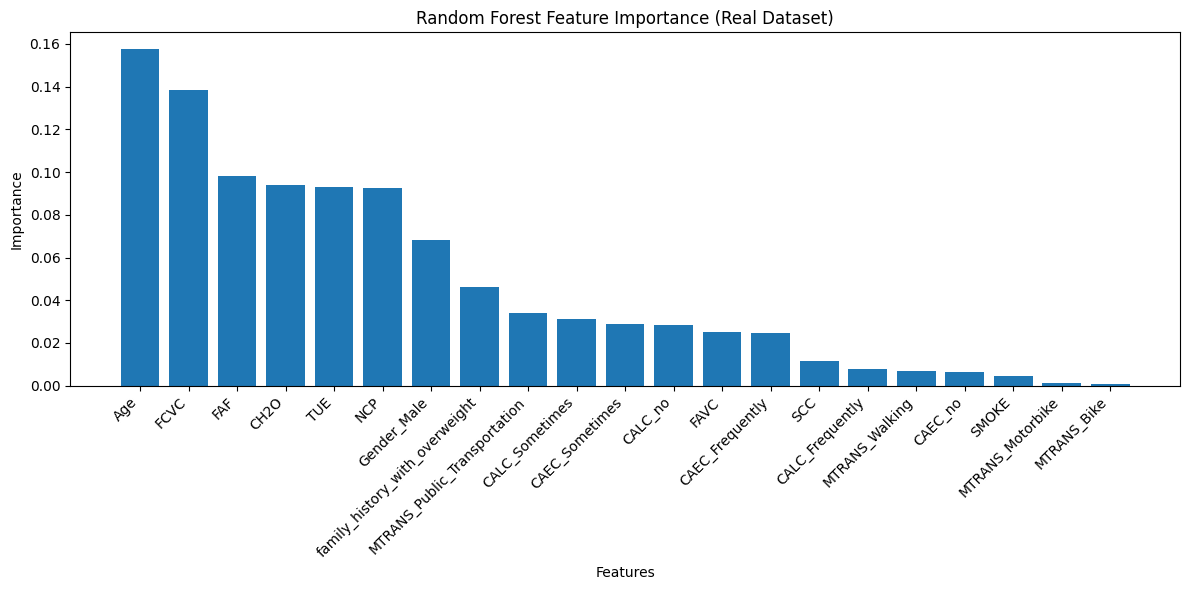


Top 5 Most Important Features:
   feature  importance
0      Age    0.157558
10    FCVC    0.138513
8      FAF    0.097986
7     CH2O    0.094027
19     TUE    0.093024


In [4]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Get the best model (Random Forest) from real dataset
rf_model = RESULTS['real']['RandomForest']['fitted_model']
feature_names = real_train_X.columns

# Feature importance plot
plt.figure(figsize=(12, 6))
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
})
importances = importances.sort_values('importance', ascending=False)

plt.bar(range(len(importances)), importances['importance'])
plt.xticks(range(len(importances)), importances['feature'], rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance (Real Dataset)')
plt.tight_layout()
plt.show()

# Print top 5 most important features
print("\nTop 5 Most Important Features:")
print(importances.head())

<Figure size 1200x800 with 0 Axes>

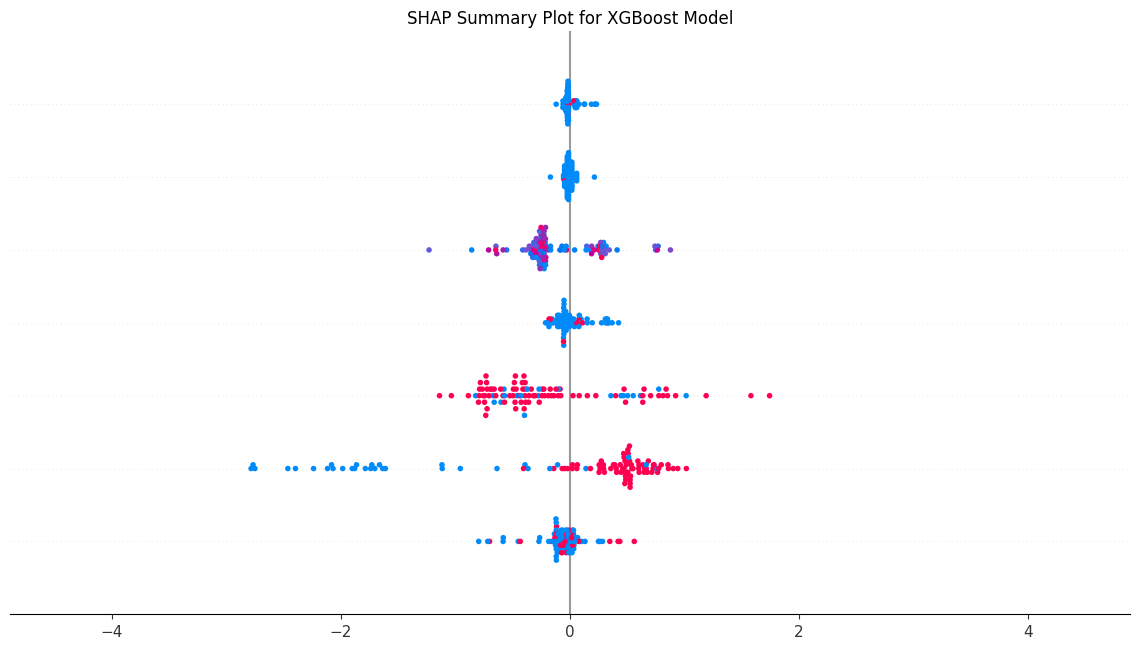

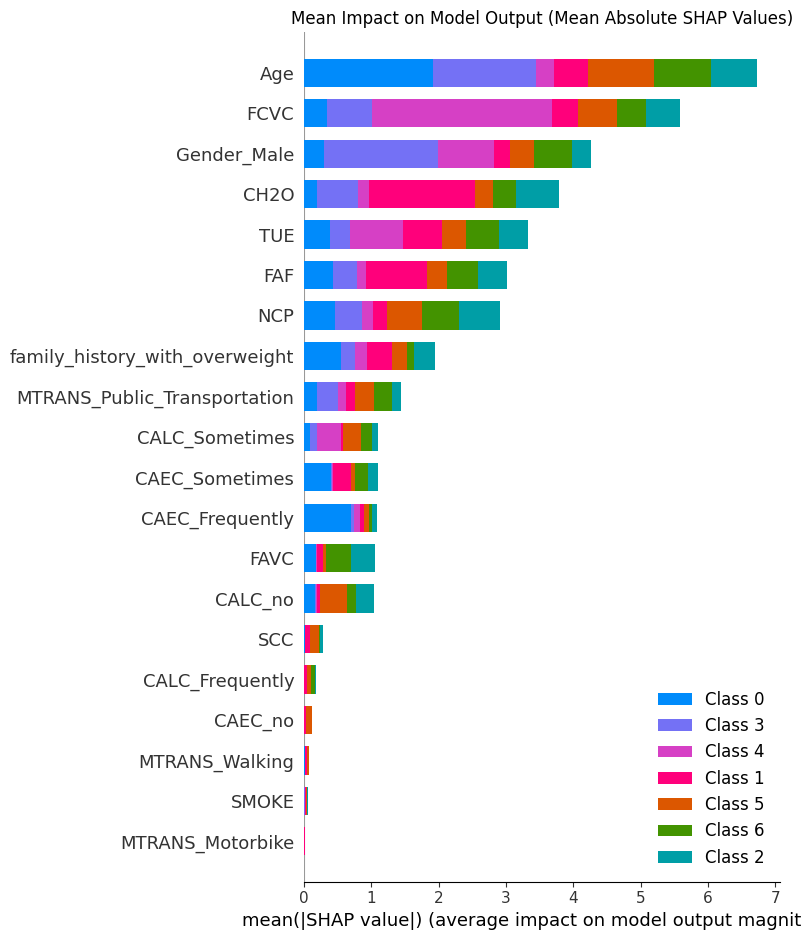

In [5]:
import shap

# Get the XGBoost model and sample data
xgb_model = RESULTS['real']['XGBoost']['fitted_model']

# Create a SHAP explainer for the model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for a subset of training data (100 samples for visualization)
shap_values = explainer.shap_values(X_train[:100])

# Create summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_train[:100], feature_names=X_train.columns, show=False)
plt.title('SHAP Summary Plot for XGBoost Model')
plt.tight_layout()
plt.show()

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_train[:100], feature_names=X_train.columns, plot_type="bar", show=False)
plt.title('Mean Impact on Model Output (Mean Absolute SHAP Values)')
plt.tight_layout()
plt.show()

In [6]:
import itertools

"""
conf_matrix:   [[50  1  0  0  0  5  0]
                [ 5 41  3  0  1  4  8]
                [ 0  8 59  6  0  2  3]
                [ 0  3  1 52  0  0  2]
                [ 0  0  0  0 63  0  0]
                [ 0 10  4  0  0 38  4]
                [ 0  3  3  8  1  3 32]]
"""
def plot_confusion_matrix(conf_matrix, title, subtitle=None, classes=None, cmap=plt.cm.Blues):
    plt.imshow(conf_matrix, interpolation='nearest', cmap=cmap)
    plt.title(title)
    if subtitle:
        plt.text(0.02, 0.02, subtitle, transform=plt.gca().transAxes, horizontalalignment='right')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')  # Added ha='right' for better alignment
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = conf_matrix.max() / 2.
    for i, j in itertools.product(range(conf_matrix.shape[0]), range(conf_matrix.shape[1])):
        plt.text(j, i, format(conf_matrix[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    # Add some padding to prevent label cutoff
    plt.subplots_adjust(bottom=0.15)
    plt.show()

Confusion Matrix for RandomForest on real dataset:


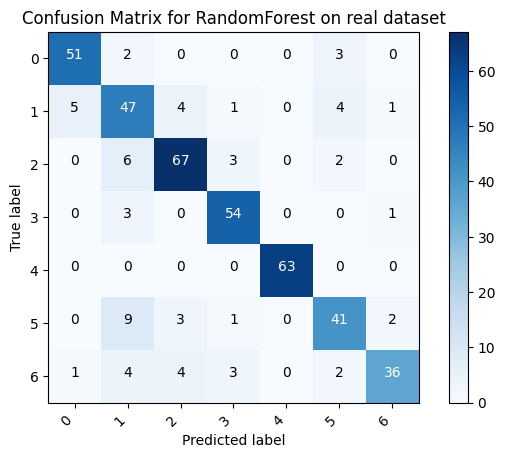

Confusion Matrix for GradientBoosting on real dataset:


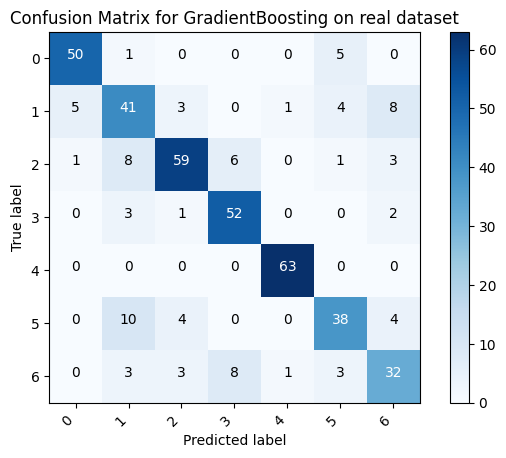

Confusion Matrix for SVM on real dataset:


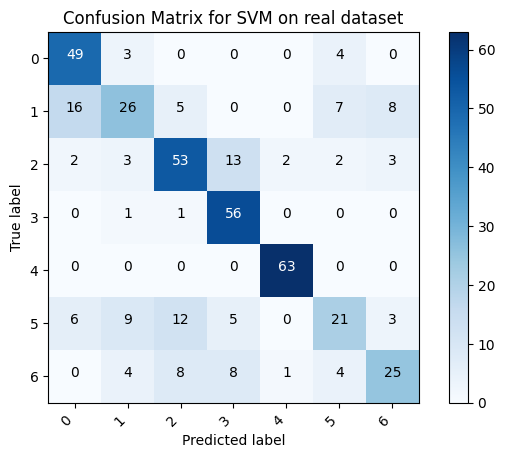

Confusion Matrix for DecisionTree on real dataset:


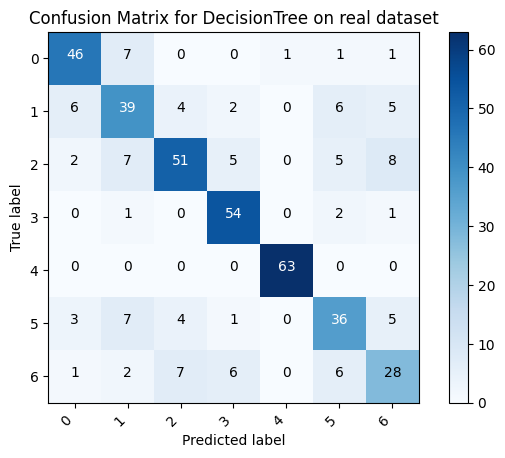

Confusion Matrix for NaiveBayes on real dataset:


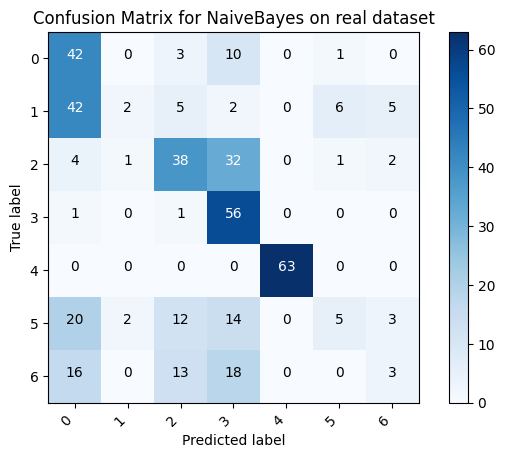

Confusion Matrix for KNN on real dataset:


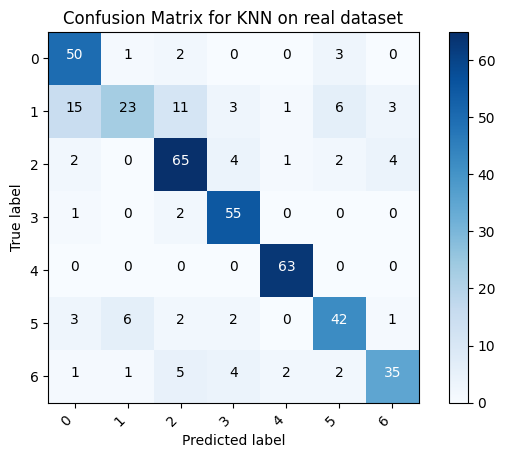

Confusion Matrix for XGBoost on real dataset:


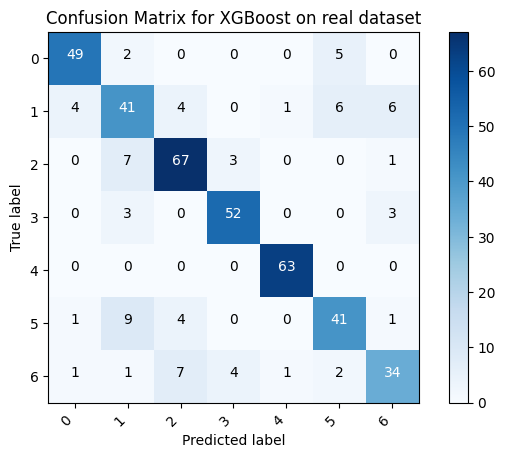

Confusion Matrix for RandomForest on synthetic dataset:


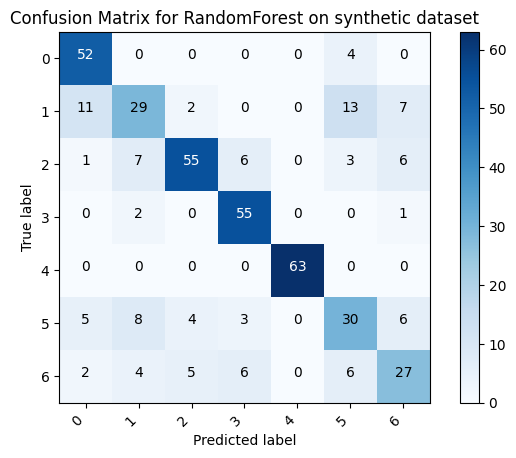

Confusion Matrix for GradientBoosting on synthetic dataset:


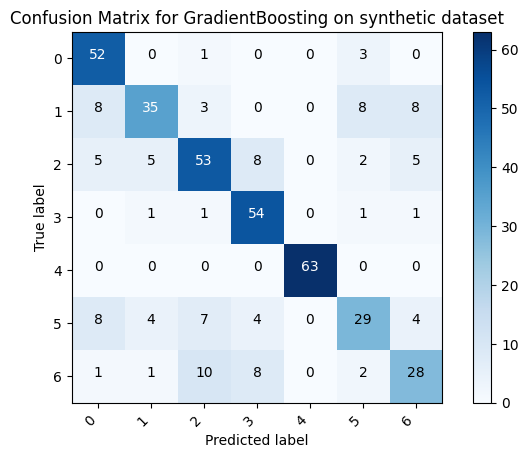

Confusion Matrix for SVM on synthetic dataset:


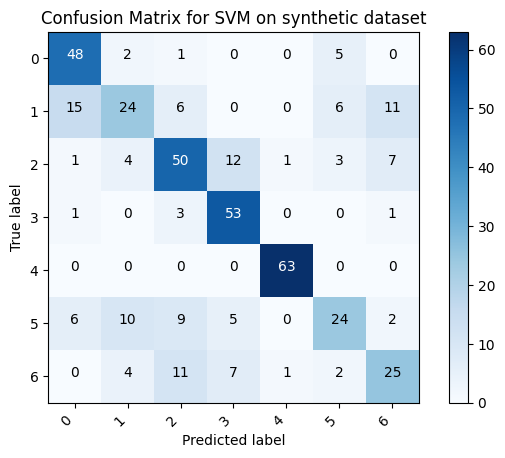

Confusion Matrix for DecisionTree on synthetic dataset:


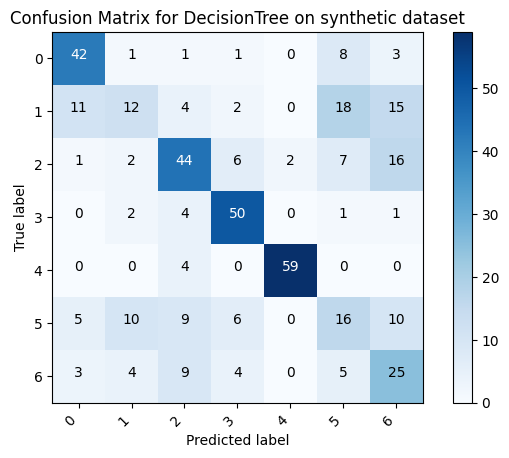

Confusion Matrix for NaiveBayes on synthetic dataset:


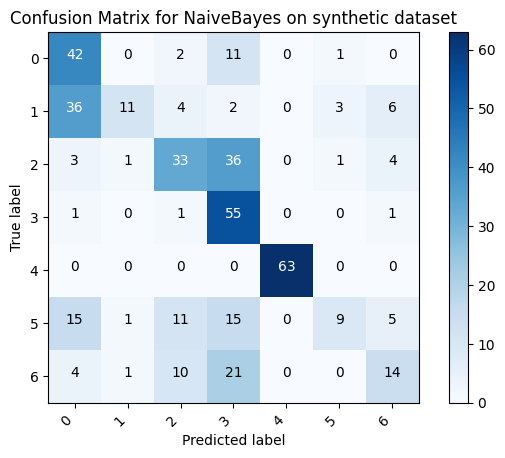

Confusion Matrix for KNN on synthetic dataset:


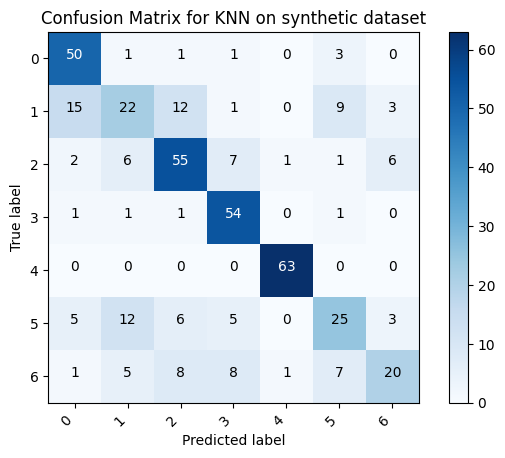

Confusion Matrix for XGBoost on synthetic dataset:


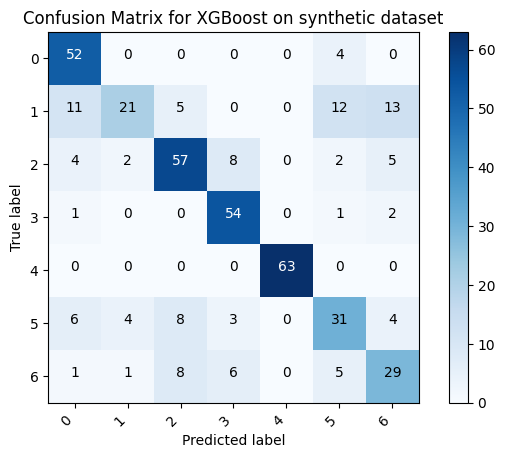

Confusion Matrix for RandomForest on concatenated dataset:


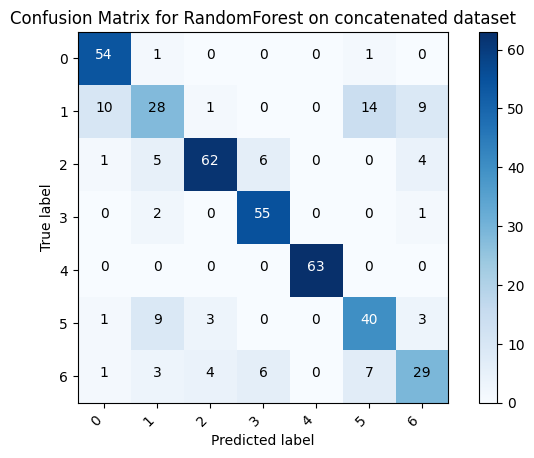

Confusion Matrix for GradientBoosting on concatenated dataset:


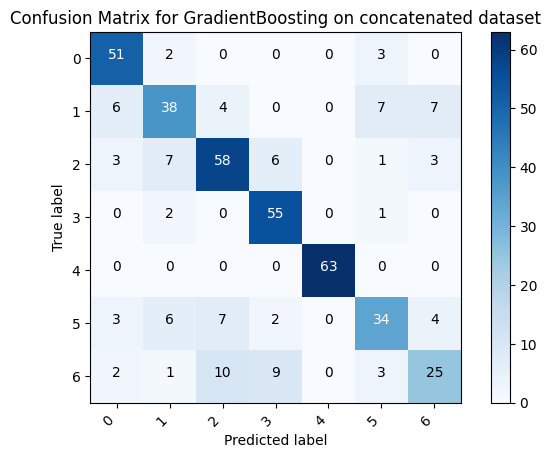

Confusion Matrix for SVM on concatenated dataset:


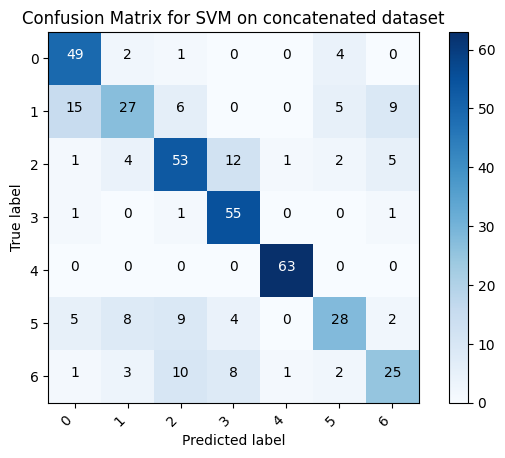

Confusion Matrix for DecisionTree on concatenated dataset:


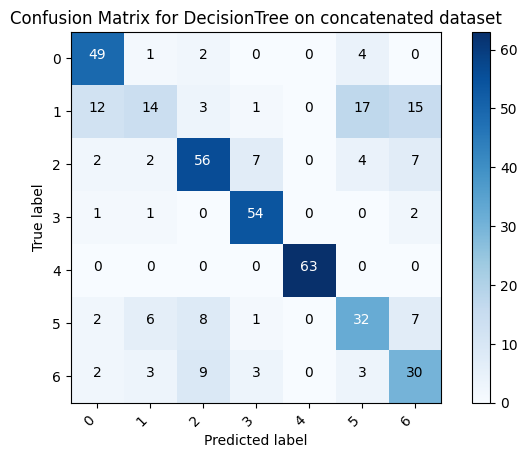

Confusion Matrix for NaiveBayes on concatenated dataset:


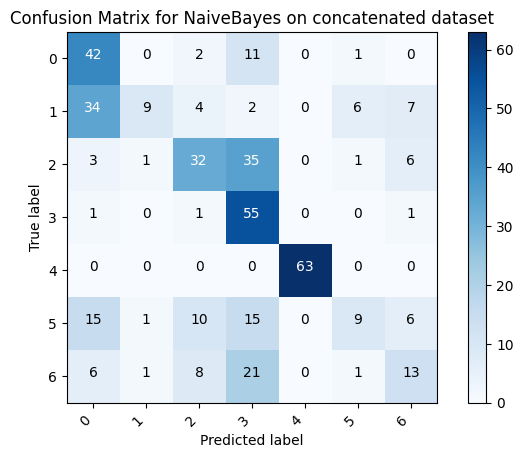

Confusion Matrix for KNN on concatenated dataset:


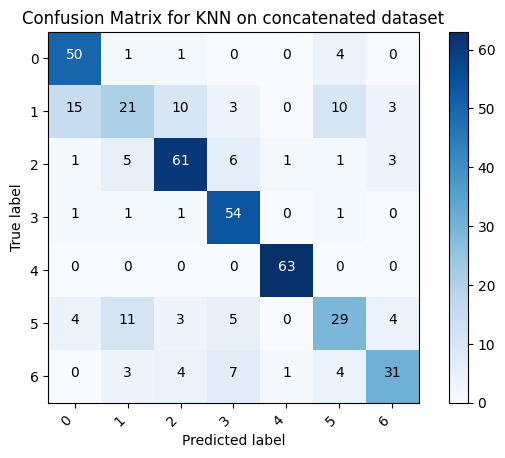

Confusion Matrix for XGBoost on concatenated dataset:


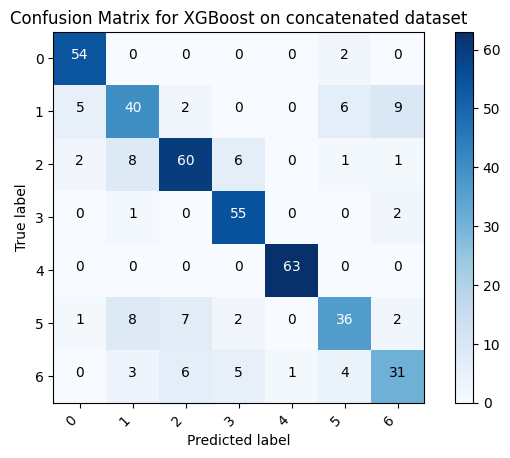

In [17]:
# Now let's do the other classifiers with proper label encoding
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# Show confusion Matrix for each Classifier trained on each dataset (in RESULTS)
for dataset_name, results in RESULTS.items():
    for clf_name, metrics in results.items():
        if clf_name == 'fitted_model':
            continue
        print(f"Confusion Matrix for {clf_name} on {dataset_name} dataset:")
        y_pred = metrics['fitted_model'].predict(X_test)
        y_test_encoded = le.fit_transform(y_test)
        conf_matrix = confusion_matrix(y_test_encoded, y_pred)
        plot_confusion_matrix(conf_matrix, title=f"Confusion Matrix for {clf_name} on {dataset_name} dataset", classes=le.classes_)

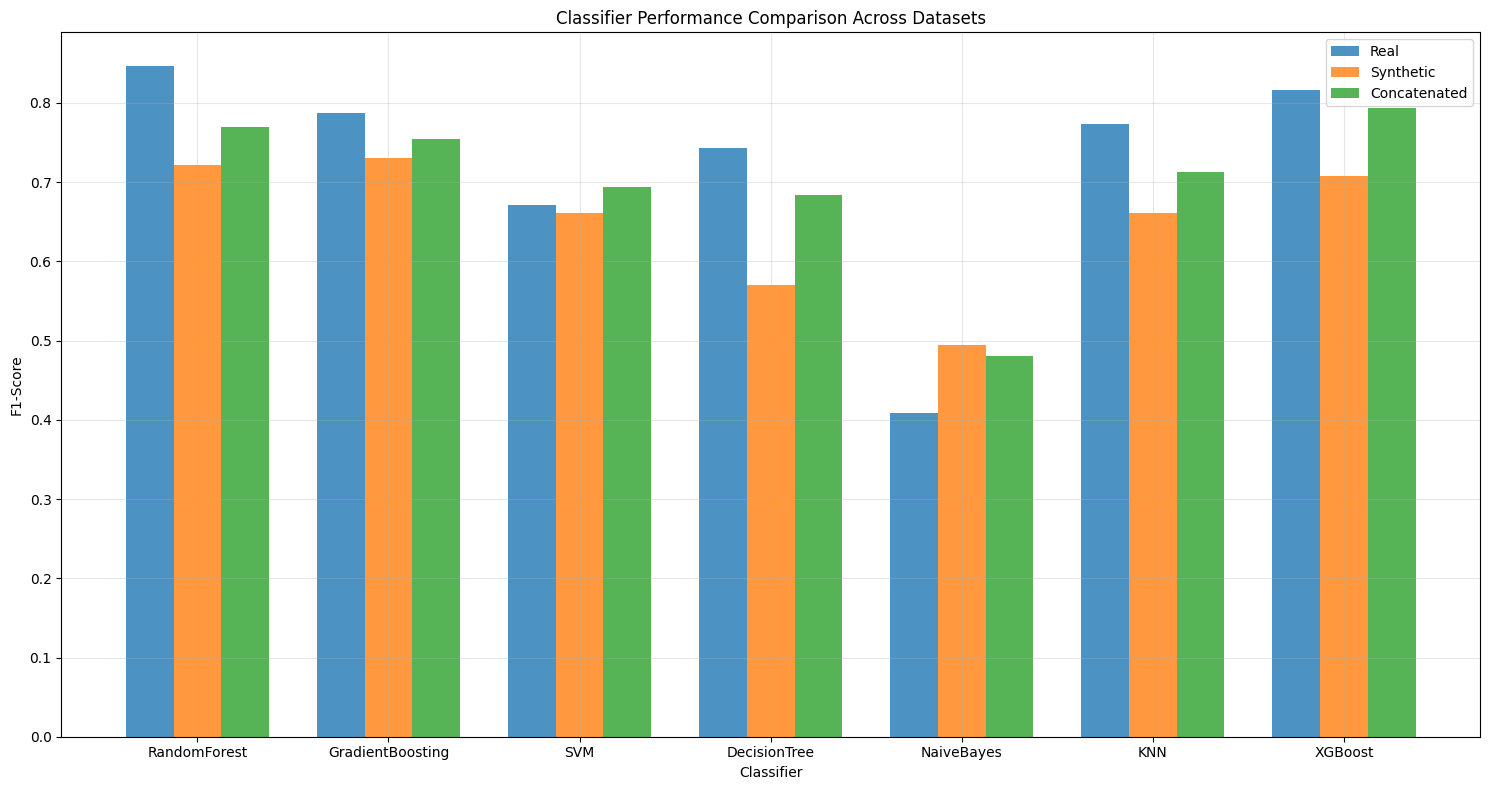

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dataframe from the results
data = []
for dataset_name, results in RESULTS.items():
    for clf_name, metrics in results.items():
        data.append({
            'Dataset': dataset_name.capitalize(),
            'Classifier': clf_name,
            'CV Accuracy': metrics['cv_accuracy'],
            'Test Accuracy': metrics['test_accuracy'],
            'Test F1-Score': metrics['test_f1']
        })

df_metrics = pd.DataFrame(data)

# Create a grouped bar plot
plt.figure(figsize=(15, 8))
metrics = ['CV Accuracy', 'Test Accuracy', 'Test F1-Score']
x = np.arange(len(df_metrics['Classifier'].unique()))
width = 0.25

for i, dataset in enumerate(df_metrics['Dataset'].unique()):
    dataset_data = df_metrics[df_metrics['Dataset'] == dataset]
    plt.bar(x + i*width, dataset_data['Test F1-Score'], 
            width, label=f'{dataset}', alpha=0.8)

plt.xlabel('Classifier')
plt.ylabel('F1-Score')
plt.title('Classifier Performance Comparison Across Datasets')
plt.xticks(x + width, df_metrics['Classifier'].unique(), ha='center')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a441f35e-4b4c-4c50-b56a-1aea6b800ed8' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>